# Data Prep: Clustering

In this notebook, the final feature matrix will be prepared for the models (both unsupervised clustering and supervised classification). This includes a short EDA, dropping / transforming of variables and, finally, saving the final dataset.

## 1) Load packages + Data

In [75]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
from matplotlib.patches import Patch

In [76]:
url = ("https://gdi.berlin.de/services/wfs/lor_2021?service=WFS&version=2.0.0"
       "&request=GetFeature&typeNames=lor_2021:a_lor_plr_2021&outputFormat=application/json")
plr = gpd.read_file(url)
plr["plr_id"] = plr["plr_id"].astype(str).str.zfill(8)

In [77]:
#load data 
df = pd.read_csv("../../data/final_datasets/feature_matrix_all_dimensions.csv", dtype={"plr_id": str})
df.sample(5)

,plr_id,plr_name,bez,re_miete_niveau,re_miete_trend,re_miete_unsicher,re_leerstandsquote,re_brw_niveau,re_brw_trend,re_brw_trend_outlier,...,com_share_min_40y_slope,com_share_solo_slope,com_share_10plus_slope,com_gastro_share_slope,com_upscale_share_slope,com_tourism_share_slope,com_entry_rate_slope,com_exit_rate_slope,com_n_gastro,com_has_gastro_structure
127,03601243,Rodenbergstraße,03 - Pankow,17.96,2.111,0,2.125229,3172.690706,-0.300655,0,...,-0.000019,0.013336,0.000888,0.000010,0.015160,-0.000182,0.001250,0.002695,40.833333,1
6,01100207,Leipziger Straße,01 - Mitte,20.13,1.065,0,2.309871,7300.667576,-0.278943,0,...,0.000749,0.022221,0.006454,0.003339,0.003864,-0.000420,0.000019,0.002128,94.833333,1
322,07601236,Marienfelder Allee Nordwest,07 - Tempelhof-Schöneberg,10.95,0.545,0,1.166055,661.255391,-0.013192,0,...,0.001682,0.011377,0.002054,0.003708,0.000686,-0.000985,-0.000826,0.002493,18.166667,1
116,03500932,Bühringstraße,03 - Pankow,16.89,0.612,0,1.970443,712.519693,-0.253294,0,...,-0.000100,0.028136,-0.009332,0.002986,-0.006494,-0.000104,0.000656,0.003225,6.666667,1
430,10100207,Ahrensfelder Berge,10 - Marzahn-Hellersdorf,7.33,0.216,0,0.874271,500.000000,-0.182322,0,...,0.002225,0.016388,-0.000310,-0.001646,0.081982,0.000000,0.002744,0.004021,2.000000,0


In [78]:
df.columns

Index(['plr_id', 'plr_name', 'bez', 're_miete_niveau', 're_miete_trend',
       're_miete_unsicher', 're_leerstandsquote', 're_brw_niveau',
       're_brw_trend', 're_brw_trend_outlier', 're_cov_wohnen_2025',
       're_dichte_all', 're_baualter_unsicher', 're_anteil_vor_1919',
       're_anteil_y1919_1948', 're_anteil_y1949_1978', 're_anteil_y1979_1990',
       're_anteil_y1991_2000', 're_anteil_y2001_2010', 're_anteil_y2011_plus',
       're_miet_dimension_anwendbar', 'soc_median_income_2023',
       'soc_young_to_middle_adult_share_2025',
       'soc_young_to_middle_adult_share_change_2021_2025',
       'soc_single_person_hh_share_2024',
       'soc_single_person_hh_share_change_2021_2024',
       'soc_households_without_minor_children_share_2024',
       'soc_households_without_minor_children_share_change_2021_2024',
       'soc_internal_migration_volume_rate_2025',
       'soc_internal_migration_volume_rate_change_2021_2025',
       'soc_internal_net_migration_rate_2025',
       '

In [79]:
df.shape

(542, 58)

## 2) NA Overview & Drops

In [80]:
#look at missing values across columns
df.isna().sum().sort_values(ascending = False)

soc_median_income_2023                                          37
re_miete_trend                                                  16
re_miete_niveau                                                 11
soc_transfer_benefit_share_2024                                  7
soc_transfer_benefit_share_change_2020_2024                      7
com_upscale_share_level_2026                                     5
re_leerstandsquote                                               5
com_upscale_share_slope                                          4
soc_young_to_middle_adult_share_2025                             4
soc_single_parent_household_share_change_2021_2024               4
soc_young_to_middle_adult_share_change_2021_2025                 4
soc_single_parent_household_share_2024                           3
soc_households_without_minor_children_share_change_2021_2024     3
soc_internal_net_migration_rate_change_2021_2025                 2
soc_internal_net_migration_rate_2025                          

In [81]:
#Decision: drop soc_median_income_2023 as it is descriptive with many NaNs
df.drop(columns=["soc_median_income_2023"], inplace = True)


In [82]:
#Look at Missings per PLR - are values missing im many PLRs or are they concentrated on some PLRs? 
id_cols = ["plr_id", "plr_name", "bez"]
feature_cols = [c for c in df.columns if c not in id_cols]

df["n_missing"] = df[feature_cols].isna().sum(axis=1)

missing_plrs = (
    df.loc[df["n_missing"] > 0, id_cols + ["n_missing"]]
      .sort_values("n_missing", ascending=False)
      .reset_index(drop=True)
)

pd.set_option("display.max_rows", None)
print(missing_plrs.to_string(index=False))
print(f"\n{len(missing_plrs)} PLRs with missing values, out of {len(df)} total")

  plr_id                          plr_name                             bez  n_missing
03400831                      Pankower Tor                     03 - Pankow         27
06200418                           Landweg        06 - Steglitz-Zehlendorf         27
05300838                        Gartenfeld                    05 - Spandau         11
10100205 Gewerbegebiet Bitterfelder Straße        10 - Marzahn-Hellersdorf          8
04400725            Güterbahnhof Grunewald 04 - Charlottenburg-Wilmersdorf          7
03300515               Blankenburger Süden                     03 - Pankow          7
12200411               Schumacher-Quartier              12 - Reinickendorf          4
07200412                Schöneberger Linse       07 - Tempelhof-Schöneberg          3
08200729                    Britzer Garten                   08 - Neukölln          2
09300921                  Preußen Siedlung           09 - Treptow-Köpenick          2
03300413                         Karow Ost            

In [83]:
# for each PLR with gaps, list what columns are missing
for _, row in missing_plrs.iterrows():
    plr_row = df.loc[df["plr_id"] == row["plr_id"]].iloc[0]
    cols = [c for c in feature_cols if pd.isna(plr_row[c])]
    print(f'{row["plr_name"]} ({row["bez"]}) — {row["n_missing"]} missing:')
    print("   ", ", ".join(cols), "\n")

Pankower Tor (03 - Pankow) — 27 missing:
    re_miete_niveau, re_miete_trend, re_leerstandsquote, re_dichte_all, re_baualter_unsicher, re_anteil_vor_1919, re_anteil_y1919_1948, re_anteil_y1949_1978, re_anteil_y1979_1990, re_anteil_y1991_2000, re_anteil_y2001_2010, re_anteil_y2011_plus, soc_young_to_middle_adult_share_2025, soc_young_to_middle_adult_share_change_2021_2025, soc_single_person_hh_share_2024, soc_single_person_hh_share_change_2021_2024, soc_households_without_minor_children_share_2024, soc_households_without_minor_children_share_change_2021_2024, soc_internal_migration_volume_rate_2025, soc_internal_migration_volume_rate_change_2021_2025, soc_internal_net_migration_rate_2025, soc_internal_net_migration_rate_change_2021_2025, soc_transfer_benefit_share_2024, soc_transfer_benefit_share_change_2020_2024, soc_single_parent_household_share_2024, soc_single_parent_household_share_change_2021_2024, com_upscale_share_level_2026 

Landweg (06 - Steglitz-Zehlendorf) — 27 missing:
   

In [84]:
#inspect NA for gastro variables 
pid = "09300921"   # Preußen Siedlung 

key = df["plr_id"].astype(str).str.zfill(8)
row = df.loc[key == pid].T          # transpose: variables become rows
row.columns = ["value"]

with pd.option_context("display.max_rows", None):
    print(row.to_string())

                                                                              value
plr_id                                                                     09300921
plr_name                                                           Preußen Siedlung
bez                                                           09 - Treptow-Köpenick
re_miete_niveau                                                               12.08
re_miete_trend                                                                0.738
re_miete_unsicher                                                                 1
re_leerstandsquote                                                         2.453988
re_brw_niveau                                                            489.689649
re_brw_trend                                                               0.064568
re_brw_trend_outlier                                                              0
re_cov_wohnen_2025                                                         0

The PLR Preußen Siedlung has an n_gastro of 0, which means that the com_upscale_share_level_2026, com_upscale_share_slope should be 0 and not NA - this can be fixed immediately.

In [85]:
pid = "09300921"   # Preußen Siedlung
key = df["plr_id"].astype(str).str.zfill(8)
cols = ["com_upscale_share_level_2026", "com_upscale_share_slope"]

df.loc[key == pid, cols] = 0.0 #set share und slope to 0.0

# verify
print(df.loc[key == pid, ["plr_name"] + cols].to_string(index=False))

        plr_name  com_upscale_share_level_2026  com_upscale_share_slope
Preußen Siedlung                           0.0                      0.0


In [86]:
#remaining missing values
df.isna().sum().sort_values(ascending = False).head(10)

re_miete_trend                                        16
re_miete_niveau                                       11
soc_transfer_benefit_share_change_2020_2024            7
soc_transfer_benefit_share_2024                        7
re_leerstandsquote                                     5
soc_single_parent_household_share_change_2021_2024     4
soc_young_to_middle_adult_share_2025                   4
com_upscale_share_level_2026                           4
soc_young_to_middle_adult_share_change_2021_2025       4
com_upscale_share_slope                                3
dtype: int64

### Plot: NA per PLR

542 von 542 gematcht


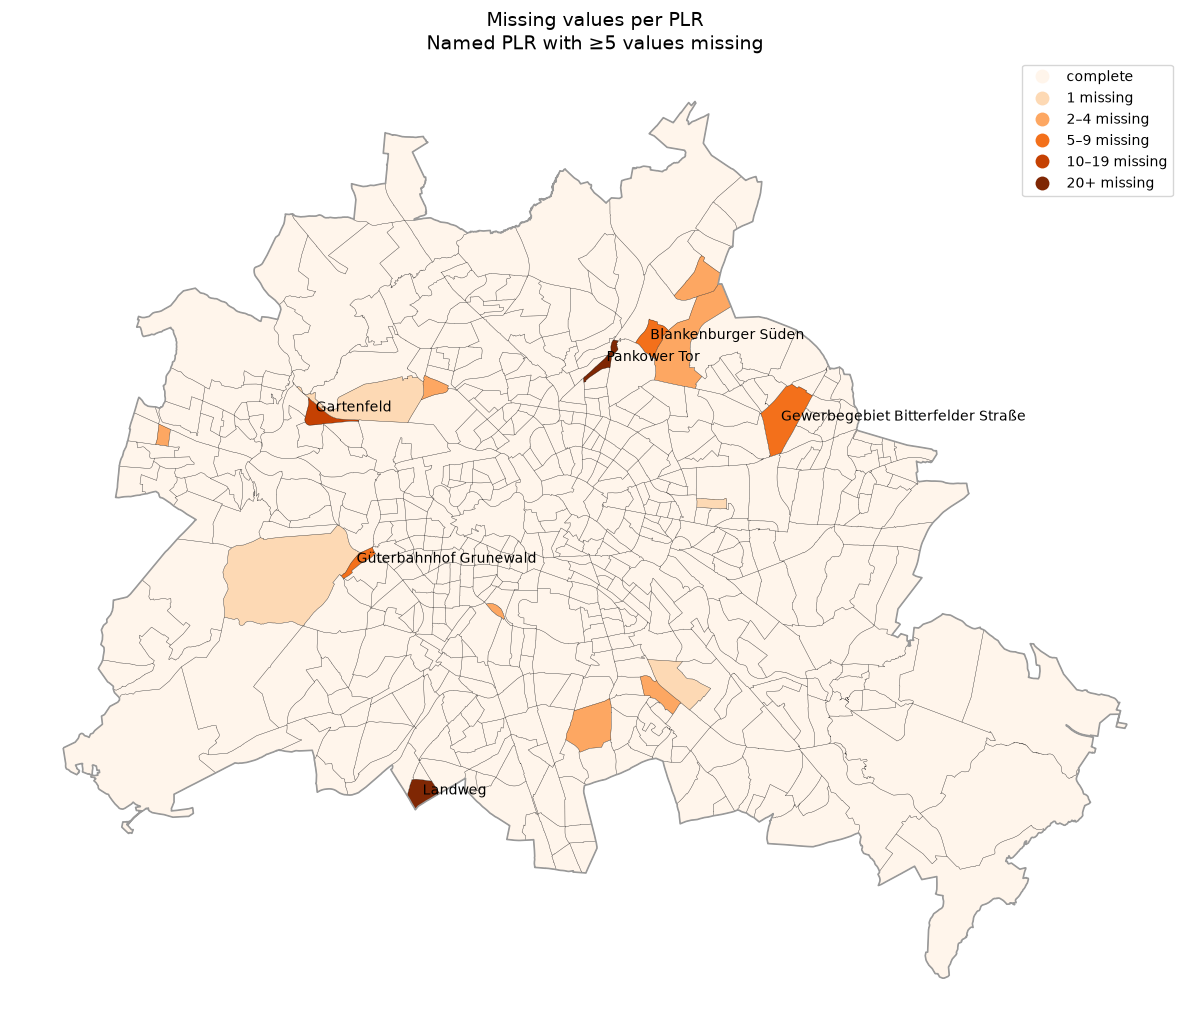

<Figure size 640x480 with 0 Axes>

In [87]:
#recompute n_missing + zero-padded join key
id_cols = ["plr_id", "plr_name", "bez"]
feature_cols = [c for c in df.columns if c not in id_cols]
df["n_missing"] = df[feature_cols].isna().sum(axis=1)

# join the counts onto the geometries
gdf = plr.merge(
    df.assign(plr_id=df["plr_id"].astype(str).str.zfill(8))[["plr_id", "n_missing"]],
    on="plr_id", how="left"
)

# sanity check — sollte ~542 sein
print(gdf["n_missing"].notna().sum(), "von", len(gdf), "gematcht")

berlin_outline = plr.dissolve()

# bin categories 
bins   = [-1, 0, 1, 4, 9, 19, np.inf]
labels = ["complete", "1 missing", "2–4 missing",
          "5–9 missing", "10–19 missing", "20+ missing"]
gdf["missing_cat"] = pd.cut(
    gdf["n_missing"].fillna(0),
    bins=bins,
    labels=labels
)

# 
fig, ax = plt.subplots(figsize=(12, 12))

# plot on map 
gdf.plot(
    column="missing_cat",
    categorical=True,
    legend=True,
    cmap="Oranges",
    edgecolor="none",
    ax=ax,
    missing_kwds={"color": "lightgrey", "label": "no geometry match"}
)

# alle plr boundary
gdf.boundary.plot(
    ax=ax,
    edgecolor="black",
    linewidth=0.25,
    alpha=0.5
)

# berlin boundary
berlin_outline.boundary.plot(
    ax=ax,
    edgecolor="#999999",
    linewidth=1.2
)

ax.set_title(
    "Missing values per PLR\nNamed PLR with ≥5 values missing",
    fontsize=14
)
ax.axis("off")

# worst offenders
for _, r in gdf[gdf["n_missing"] >= 5].iterrows():
    c = r.geometry.representative_point()
    ax.annotate(
        r["plr_name"],
        (c.x, c.y),
        fontsize=10,
        ha="left"
    )

plt.tight_layout()
plt.show()

plt.savefig("../../plots/EDA/NaNs_per_PLR.png", dpi=300, bbox_inches="tight")

#Result of inspecting the NaNs

Missing values are highly concentrated, not dispersed: 499 of 542 PLR are complete. The most affected — Landweg and Pankower Tor (27 each), plus Gartenfeld, Gewerbegebiet Bitterfelder Straße, Blankenburger Süden, Güterbahnhof Grunewald, and Schumacher-Quartier — are development sites, former railway/industrial land, and barely-populated quarters that legitimately lack structure across all three dimensions and are therefore dropped from the dataset. 



In [88]:
#drop PLRs that are non-residential (more )
non_residential = {
    "06200418": "Landweg",
    "03400831": "Pankower Tor",
    "05300838": "Gartenfeld",
    "10100205": "Gewerbegebiet Bitterfelder Straße",
    "03300515": "Blankenburger Süden",
    "04400725": "Güterbahnhof Grunewald",
    "12200411": "Schumacher-Quartier",
}
                      
df_model = df[~df["plr_id"].isin(non_residential)].copy()   
print(f"Dropped {len(non_residential)} non-residential PLR → {len(df_model)} remain")  

Dropped 7 non-residential PLR → 535 remain


In [89]:
#sanity check
print(f"Rows in newly created df_model: {len(df_model)}")
dropped = set(df["plr_id"]) - set(df_model["plr_id"])
print("Dropped PLR:")
print(df[df["plr_id"].isin(dropped)][["plr_id", "plr_name"]].to_string(index=False))

Rows in newly created df_model: 535
Dropped PLR:
  plr_id                          plr_name
03300515               Blankenburger Süden
03400831                      Pankower Tor
04400725            Güterbahnhof Grunewald
05300838                        Gartenfeld
06200418                           Landweg
10100205 Gewerbegebiet Bitterfelder Straße
12200411               Schumacher-Quartier


Now let's inspect the missings without those PLRs, where is only one feature missing in a PLRs. 

In [90]:
#inspect remaining missingness
n = len(df_model)
miss = df_model.isna().sum()
overview = pd.DataFrame({
    "n_missing": miss,
    "pct": (miss / n * 100).round(1),
})
overview = overview[overview["n_missing"] > 0].sort_values("n_missing", ascending=False)
print(overview)

                    n_missing  pct
re_miete_trend              9  1.7
re_miete_niveau             5  0.9
re_brw_niveau               1  0.2
re_brw_trend                1  0.2
re_cov_wohnen_2025          1  0.2


In [91]:
rent_cols = ["re_miete_niveau", "re_miete_trend"]
brw_cols  = ["re_brw_niveau", "re_brw_trend", "re_cov_wohnen_2025"]
all_gap   = rent_cols + brw_cols

#which block is missing for each affected PLR
affected = df_model[df_model[all_gap].isna().any(axis=1)].copy()

def missing_block(row):
    rent_missing = row[rent_cols].isna().any()
    brw_missing  = row[brw_cols].isna().any()
    if rent_missing and brw_missing: return "rent+brw"
    if rent_missing:                 return "rent only"
    if brw_missing:                  return "brw only"
    return "-"

affected["missing_block"] = affected.apply(missing_block, axis=1)

print(affected[["plr_id", "plr_name",
                "re_miete_niveau", "re_miete_trend",
                "re_brw_niveau", "re_cov_wohnen_2025",
                "re_miete_unsicher", "missing_block"]].to_string(index=False))

  plr_id           plr_name  re_miete_niveau  re_miete_trend  re_brw_niveau  re_cov_wohnen_2025  re_miete_unsicher missing_block
03300413          Karow Ost              NaN             NaN     500.022367            0.959013                  1     rent only
03300517        Märchenland              NaN             NaN     285.571015            0.115828                  1     rent only
04200207           Eichkamp            16.67             NaN     996.036121            0.034252                  1     rent only
05200419       Am Heideberg              NaN             NaN     469.435055            0.928344                  1     rent only
07200412 Schöneberger Linse            22.60           0.854            NaN                 NaN                  0      brw only
08200728         Ortolanweg              NaN             NaN     600.000000            0.084402                  1     rent only
08200729     Britzer Garten              NaN             NaN     625.333179            0.109536  

Rent data is missing in 9 PLRs, BRW data is missing in one PLR (Schöneberger Linse): 

Domain knowledge: Schöneberger Linse wasn't a residential area in 2022 and therefore doesn't have a BRW value. However, now it is a gentrifying kiez that should be taken into account. 

In [92]:
#two hypotheses why the rent data is missing: Neubaugebiete or non-residential? 

#bring fallzahl_mittel in from the angebotsmieten source (not in the merged matrix) ---
src = pd.read_csv("../../data/real_estate/final_variables/var1_2_angebotsmieten.csv", dtype={"plr_id": str})  # adjust path
src["plr_id"] = src["plr_id"].str.zfill(8)
df_check = df_model.merge(src[["plr_id", "fallzahl_mittel"]], on="plr_id", how="left")

#neubau share (or reuse re_neubau_share if already derived)
df_check["neubau_share"] = df_check["re_anteil_y2001_2010"] + df_check["re_anteil_y2011_plus"]

#therefore: two missingness groups
group_a = ["03300413", "03300517", "05200419", "08200728", "08200729"]  # fallzahl NaN: no offers -> niveau+trend missing
group_b = ["04200207", "09100306", "11300723", "12200414"]              # fallzahl 3-4: niveau present, trend missing

cols = ["plr_id", "plr_name", "fallzahl_mittel",
        "re_cov_wohnen_2025", "neubau_share", "re_anteil_vor_1919"]

print("GROUP A — no rental offers (fallzahl NaN):")
print(df_check[df_check["plr_id"].isin(group_a)][cols].round(3).to_string(index=False))
print("\nGROUP B — too few offers for a trend (fallzahl 3–4):")
print(df_check[df_check["plr_id"].isin(group_b)][cols].round(3).to_string(index=False))

GROUP A — no rental offers (fallzahl NaN):
  plr_id       plr_name  fallzahl_mittel  re_cov_wohnen_2025  neubau_share  re_anteil_vor_1919
03300413      Karow Ost              NaN               0.959         0.270               0.022
03300517    Märchenland              NaN               0.116         0.031               0.006
05200419   Am Heideberg              NaN               0.928         0.000               0.754
08200728     Ortolanweg              NaN               0.084         0.000               0.009
08200729 Britzer Garten              NaN               0.110         0.179               0.017

GROUP B — too few offers for a trend (fallzahl 3–4):
  plr_id      plr_name  fallzahl_mittel  re_cov_wohnen_2025  neubau_share  re_anteil_vor_1919
04200207      Eichkamp              3.0               0.034         0.021               0.023
09100306   Späthsfelde              3.0               0.242         0.141               0.027
11300723 Bornitzstraße              3.0            

None of the hypotheses are true:

Karow Ost (cov 0.96), Eichkamp (cov 0.03, fallzahl 3) and Am Heideberg (cov 0.93, 75% Altbau) are strongly residential but owner-occupied areas that don't generate rental listings. Märchenland/Ortolanweg/Britzer Garten are low-coverage green-edge areas or small peripheral settlement with minimal rental (Späthsfelde, cov 0.24, fallzahl 3). 

These will therefore be excluded from the dataset for modelling. Only Bornitzstraße is newly-built. All the rest is neither newly-built nor non-residential. 

Small caveat: building age is based on the Zensus 2022 Gebäude- und Wohnungszählung (Stichtag 15 May 2022) and therefore reflects the building stock as of that date. Construction completed after May 2022 is not captured, so PLR with major post-2022 development (e.g. the Schumacher-Quartier redevelopment) will under-represent their actual Neubau share. 

Schöneberger Linse with the BRW missing is - as stated already - a separate case. So is Bornitzstraße. 

In [93]:
#PLR with no tenant structure (owner-occupied) or predominantly garden/green —
no_tenant_structure = {
    "03300413": "Karow Ost",        #residential but zero rental offers — owner-occupied
    "05200419": "Am Heideberg",     #residential, no rental market — owner-occupied
    "03300517": "Märchenland",      #low coverage, no offers — garden/Siedlung
    "08200728": "Ortolanweg",       #low coverage, no offers — half garden
    "08200729": "Britzer Garten",   #park-adjacent, no offers — garden
    "04200207": "Eichkamp",         #villa colony, minimal rental — owner-occupied
    "09100306": "Späthsfelde",      #small peripheral settlement, minimal rental
    "12200414": "Tegel",            #2022 still the airport, 2026 no residential area yet built
    
}

df_model = df_model[~df_model["plr_id"].isin(no_tenant_structure)].copy()
print(f"Dropped {len(no_tenant_structure)} non-tenant PLR → {len(df_model)} remain")

Dropped 8 non-tenant PLR → 527 remain


### 3) Recoding Baualter Variable (sums up to 1 currently)

In [94]:
#derive two Baualter features, one with old buildings (altbau_share, Gründerzeit)
df_model["re_altbau_share"] = df_model["re_anteil_vor_1919"] 
#and one with newer buildings (from 2001 onwards)                      
df_model["re_neubau_share"] = (
    df_model["re_anteil_y2001_2010"] + df_model["re_anteil_y2011_plus"]            # 2001+
)

#energetic-modernisation potential is the complement of Neubau 
#However: NOT stored as a feature (near-constant + overlaps Altbau): 1 - re_neubau_share

#drop the 7 original bands (collapsed into the two shares above)
baualter_bands = [
    "re_anteil_vor_1919", "re_anteil_y1919_1948", "re_anteil_y1949_1978",
    "re_anteil_y1979_1990", "re_anteil_y1991_2000",
    "re_anteil_y2001_2010", "re_anteil_y2011_plus",
]
df_model = df_model.drop(columns=baualter_bands)

#verify the two new shares aren't redundant with each other or the market
checks = ["re_altbau_share", "re_neubau_share", "re_miete_niveau", "re_brw_niveau"]
print(df_model[checks].corr(method="spearman").round(2).to_string())
print(f"\nColumns now: {df_model.shape[1]}")

                 re_altbau_share  re_neubau_share  re_miete_niveau  re_brw_niveau
re_altbau_share             1.00            -0.04             0.61           0.73
re_neubau_share            -0.04             1.00             0.30          -0.11
re_miete_niveau             0.61             0.30             1.00           0.62
re_brw_niveau               0.73            -0.11             0.62           1.00

Columns now: 53


## 3) Exploration: Flag Variables

527 von 542 gematcht


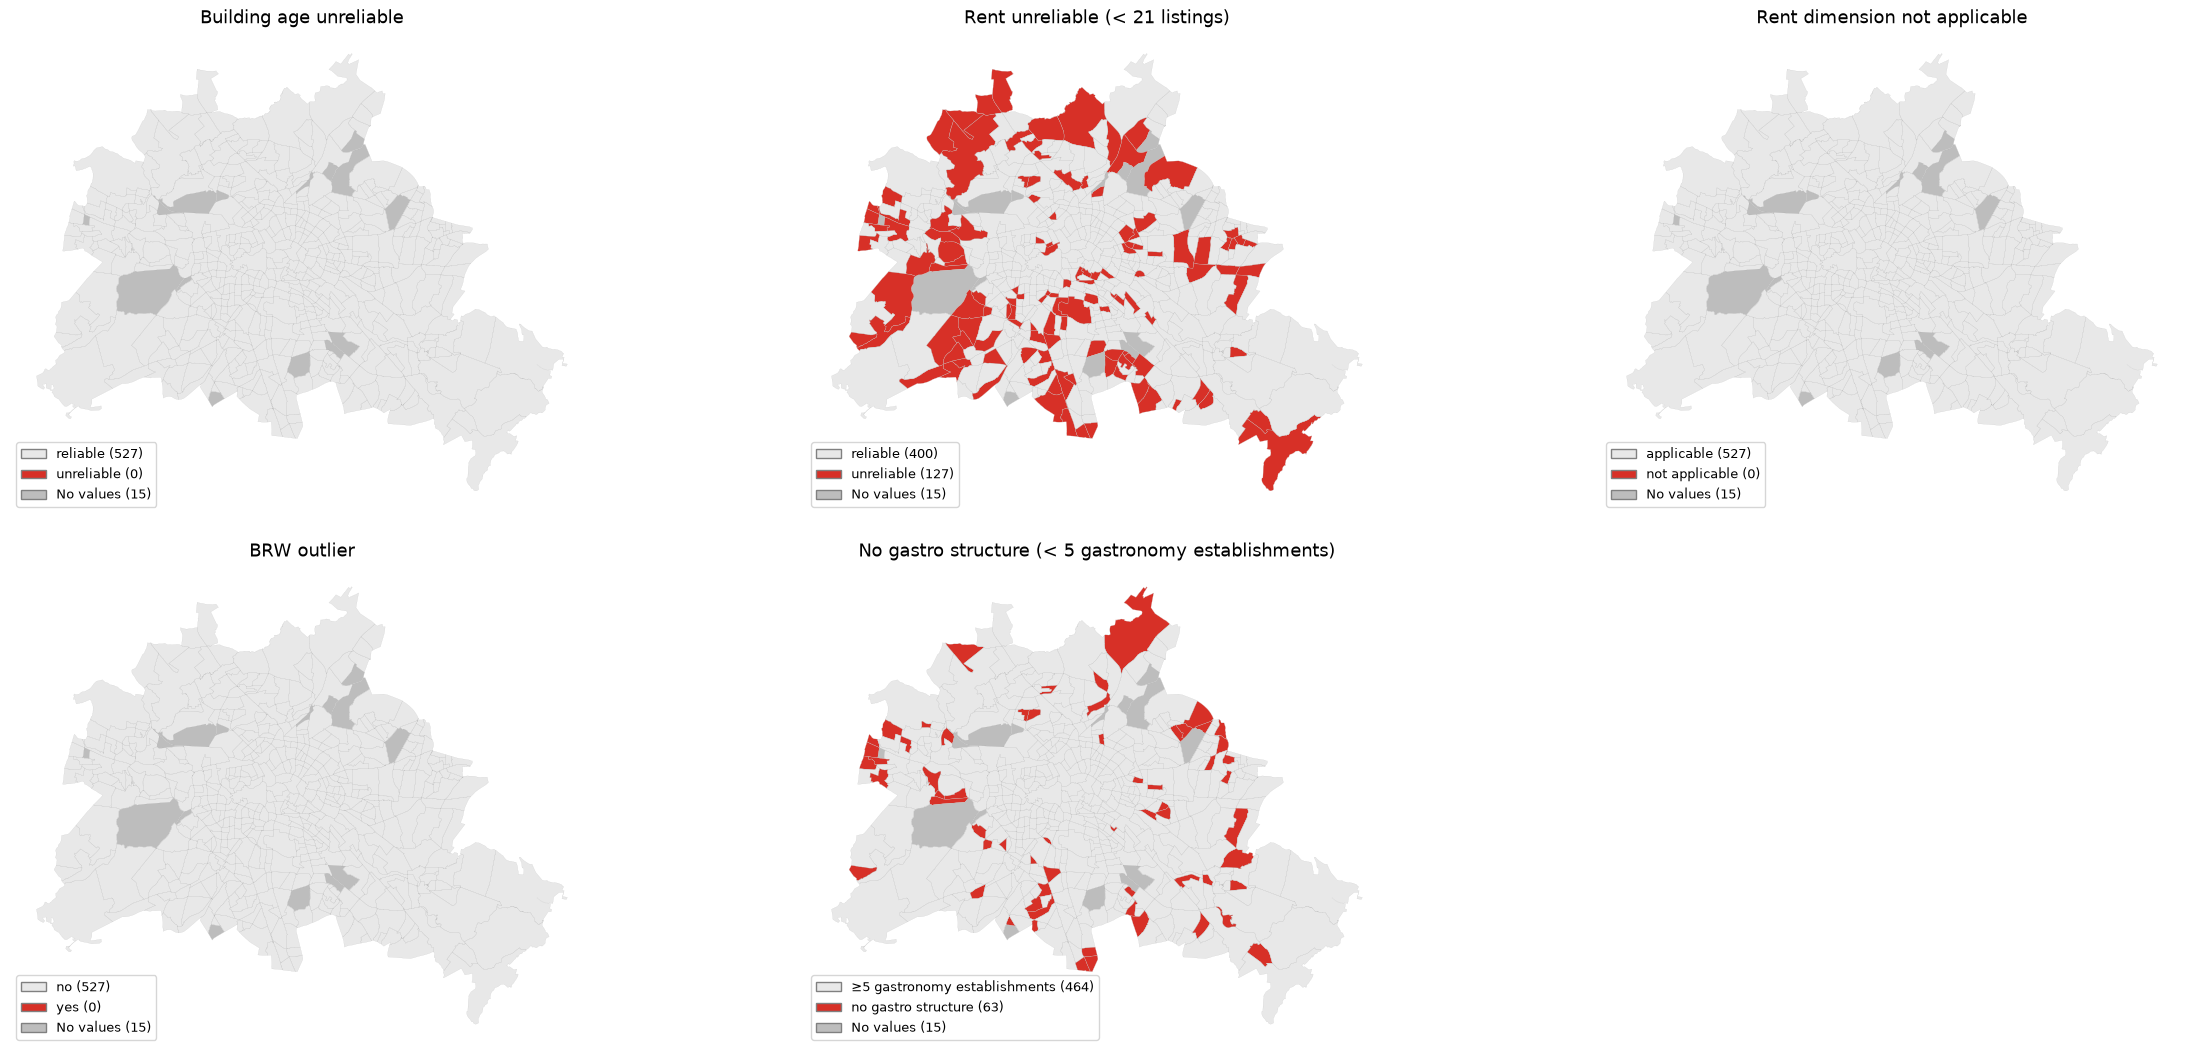

In [95]:
flags = ["re_baualter_unsicher", "re_miete_unsicher",
         "re_miet_dimension_anwendbar", "re_brw_trend_outlier","com_has_gastro_structure"]

df_flags = df_model.assign(plr_id=df["plr_id"].astype(str).str.zfill(8))[["plr_id"] + flags]
gdf = plr.merge(df_flags, on="plr_id", how="left")
print(gdf[flags].notna().any(axis=1).sum(), "von", len(gdf), "gematcht")

flag_styles = {
    "re_baualter_unsicher": {"title": "Building age unreliable",
        "map": {0: ("reliable", "#e8e8e8"), 1: ("unreliable", "#d73027")}},
    "re_miete_unsicher": {"title": "Rent unreliable (< 21 listings)",
        "map": {0: ("reliable", "#e8e8e8"), 1: ("unreliable", "#d73027")}},
    "re_miet_dimension_anwendbar": {"title": "Rent dimension not applicable",
        "map": {1: ("applicable", "#e8e8e8"), 0: ("not applicable", "#d73027")}},
    "re_brw_trend_outlier": {"title": "BRW outlier",
        "map": {0: ("no", "#e8e8e8"), 1: ("yes", "#d73027")}},
    "com_has_gastro_structure": {"title": "No gastro structure (< 5 gastronomy establishments)",
        "map": {1: ("≥5 gastronomy establishments", "#e8e8e8"), 0: ("no gastro structure", "#d73027")}}
}

fig, axes = plt.subplots(3, 3, figsize=(24, 16))

for ax, (col, style) in zip(axes.flat, flag_styles.items()):
    vmap = style["map"]
    colors = gdf[col].map({k: v[1] for k, v in vmap.items()}).fillna("#bdbdbd")
    gdf.plot(ax=ax, color=colors, edgecolor="white", linewidth=0.15)
    gdf.boundary.plot(ax=ax, edgecolor="black", linewidth=0.1, alpha=0.3)

    counts = gdf[col].value_counts(dropna=False)
    handles = [Patch(facecolor=v[1], edgecolor="grey",
                     label=f"{v[0]} ({int(counts.get(k, 0))})")
               for k, v in vmap.items()]
    if gdf[col].isna().any():
        handles.append(Patch(facecolor="#bdbdbd", edgecolor="grey",
                             label=f"No values ({int(gdf[col].isna().sum())})"))
    ax.legend(handles=handles, loc="lower left", fontsize=9, frameon=True)
    ax.set_title(style["title"], fontsize=13)
    ax.axis("off")

# leere Zellen ausblenden (hier die 6.)
for ax in axes.flat[len(flag_styles):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

In [96]:
#Which PLR still flagged? (check only flags still present in df_model)
for flag in ["re_baualter_unsicher", "re_brw_trend_outlier", "re_miet_dimension_anwendbar", "re_miete_unsicher", "com_has_gastro_structure"]:
    if flag not in df_model.columns:
        print(f"{flag}: already dropped\n")
        continue
    n_flagged = (df_model[flag] == 1).sum()
    print(f"{flag}:")
    print(f"  PLR flagged == 1: {n_flagged}")
    print(f"  Distinct values: {df_model[flag].nunique()}")
    print(df_model[flag].value_counts(dropna=False).to_string())
    print()

re_baualter_unsicher:
  PLR flagged == 1: 0
  Distinct values: 1
re_baualter_unsicher
0.0    527

re_brw_trend_outlier:
  PLR flagged == 1: 0
  Distinct values: 1
re_brw_trend_outlier
0    527

re_miet_dimension_anwendbar:
  PLR flagged == 1: 527
  Distinct values: 1
re_miet_dimension_anwendbar
1    527

re_miete_unsicher:
  PLR flagged == 1: 127
  Distinct values: 2
re_miete_unsicher
0    400
1    127

com_has_gastro_structure:
  PLR flagged == 1: 464
  Distinct values: 2
com_has_gastro_structure
1    464
0     63



In [97]:
#decision: drop them as they are a constant after dropping 8 PLRs

df_model = df_model.drop(columns=[c for c in
    ["re_baualter_unsicher", "re_brw_trend_outlier", "re_miet_dimension_anwendbar"]
    if c in df_model.columns])
print(df_model.shape)

#decision 2: drop the other ones too because they are redudant in the model and binary 
df_model = df_model.drop(columns=[c for c in
    ["com_has_gastro_structure", "re_miete_unsicher"]
    if c in df_model.columns])
print(df_model.shape)


(527, 50)
(527, 48)


## 4) Correlation Matrix 

In [98]:
#build numeric column list from the CURRENT modeling frame
id_label = ["plr_id", "plr_name", "bez"]
num_cols = [c for c in df_model.columns if c not in id_label]

#drop helper columns and the remaining flag
cols_to_use = [
    c for c in num_cols
    if not c.endswith("_unsicher") and not c.startswith("com_has_")
]

#Spearman correlation matrix
corr = df_model[cols_to_use].corr(method="spearman")

#every unique pair once
results = []
for i in range(len(cols_to_use)):
    for j in range(i + 1, len(cols_to_use)):       # j > i: no duplicates/self-pairs
        var_a, var_b = cols_to_use[i], cols_to_use[j]
        rho = corr.loc[var_a, var_b]
        dim_a = var_a.split("_")[0]                 # "re" / "soc" / "com"
        dim_b = var_b.split("_")[0]
        results.append({
            "var_a": var_a,
            "var_b": var_b,
            "rho": rho,
            "abs_rho": abs(rho),
            "cross_dim": dim_a != dim_b,
        })

pairs = pd.DataFrame(results)

#redundancy-suspect pairs: |rho| > 0.95
high = pairs[pairs["abs_rho"] > 0.95].sort_values("abs_rho", ascending=False)
print(f"Variable pairs with |rho| > 0.95: {len(high)}")
print(high[["var_a", "var_b", "rho", "cross_dim"]].to_string(index=False))

#early warning: strong cross-dimension pairs |rho| > 0.8
cross_strong = pairs[(pairs["cross_dim"]) & (pairs["abs_rho"] > 0.8)].sort_values("abs_rho", ascending=False)
print(f"\nCross-dimension pairs with |rho| > 0.8: {len(cross_strong)}")
print(cross_strong[["var_a", "var_b", "rho"]].to_string(index=False))

Variable pairs with |rho| > 0.95: 0
Empty DataFrame
Columns: [var_a, var_b, rho, cross_dim]
Index: []

Cross-dimension pairs with |rho| > 0.8: 0
Empty DataFrame
Columns: [var_a, var_b, rho]
Index: []


In [99]:
print(df_model.columns.tolist())

['plr_id', 'plr_name', 'bez', 're_miete_niveau', 're_miete_trend', 're_leerstandsquote', 're_brw_niveau', 're_brw_trend', 're_cov_wohnen_2025', 're_dichte_all', 'soc_young_to_middle_adult_share_2025', 'soc_young_to_middle_adult_share_change_2021_2025', 'soc_single_person_hh_share_2024', 'soc_single_person_hh_share_change_2021_2024', 'soc_households_without_minor_children_share_2024', 'soc_households_without_minor_children_share_change_2021_2024', 'soc_internal_migration_volume_rate_2025', 'soc_internal_migration_volume_rate_change_2021_2025', 'soc_internal_net_migration_rate_2025', 'soc_internal_net_migration_rate_change_2021_2025', 'soc_transfer_benefit_share_2024', 'soc_transfer_benefit_share_change_2020_2024', 'soc_single_parent_household_share_2024', 'soc_single_parent_household_share_change_2021_2024', 'com_median_age_level_2026', 'com_share_solo_level_2026', 'com_share_10plus_level_2026', 'com_gastro_share_level_2026', 'com_upscale_share_level_2026', 'com_tourism_share_level_2026

In [100]:
df_model = df_model.drop(columns="n_missing")

In [101]:
df_model.shape

(527, 47)

In [102]:
#save the new dataset 

out_path = "../../data/final_datasets/dataset_0.csv"
df_model.to_csv(out_path, index=False)
print(f"Saved {df_model.shape[0]} PLR × {df_model.shape[1]} cols → {out_path}")

Saved 527 PLR × 47 cols → ../../data/final_datasets/dataset_0.csv


In [103]:
#sanity check 
check = pd.read_csv("../../data/final_datasets/dataset_0.csv", dtype={"plr_id": str})
print(check.shape)                                  # (527, 49)
print(check["plr_id"].iloc[0], "len:", len(check["plr_id"].iloc[0]))   # 8-stellig

(527, 47)
01100101 len: 8


Final dataset done 

- unequal amount of variables per dimension, commercial dimension currently would count double --> to be discussed at the clustering 
- Missings in 2 PLR: Bornitzstraße and Schöneberger Linse are to be KNN imputed at the modeling stage. 